In [1]:
import sys
import os

# 1. Get the absolute path to the project root 
# Based on your image, analysis.ipynb is in: eb_jepa/examples/image_jepa_ssl/notebooks/
# We need to go up 3 levels to reach the directory containing 'eb_jepa'
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))

# 2. Add it to the path if it's not already there
if root_path not in sys.path:
    sys.path.append(root_path)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.optim.optimizer import required
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import MNIST
from tqdm import tqdm

from eb_jepa.losses import VICRegLoss
from eb_jepa.training_utils import (
    setup_device,
    setup_seed,
)
from examples.image_jepa.dataset import (
    ImageDataset,
    get_train_transforms,
    get_val_transforms,
)

In [3]:
import timm

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

import torch
import torch.utils.data
import torchvision.transforms as transforms
from examples.image_jepa.dataset import *

def get_train_transforms():
    """Get training transforms for self-supervised learning."""
    transform = transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=3),
            RandomResizedCrop(32, scale=(0.2, 1.0)),
            ColorJitter(
                brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1, prob=0.8
            ),
            Grayscale(prob=0.2),
            Solarization(prob=0.1),
            HorizontalFlip(prob=0.5),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    return transform


In [5]:
from examples.image_jepa.main import ResNet18

In [6]:
"""
class ResNet18(nn.Module):
    ""ResNet-18 backbone implementation.""

    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.resnet18()
        self.backbone.fc = nn.Identity()  # Remove final classification layer
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=2, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        self.features_dim = 512

    def forward(self, x):
        return self.backbone(x)
"""

'\nclass ResNet18(nn.Module):\n    ""ResNet-18 backbone implementation.""\n\n    def __init__(self):\n        super().__init__()\n        self.backbone = torchvision.models.resnet18()\n        self.backbone.fc = nn.Identity()  # Remove final classification layer\n        self.backbone.conv1 = nn.Conv2d(\n            3, 64, kernel_size=3, stride=1, padding=2, bias=False\n        )\n        self.backbone.maxpool = nn.Identity()\n        self.features_dim = 512\n\n    def forward(self, x):\n        return self.backbone(x)\n'

In [7]:
DEVICE = "cuda"
SEED = 42
DATA_DIR = "/data"
BATCH_SIZE = 256
NUM_WORKERS = 4
LR = 1.0e-3
EPOCHS = 100
WARMUP_EPOCHS = 10

In [8]:
"""
class ImageSSL(nn.Module):
    ""Image Self-Supervised Learning model implementation.""

    def __init__(
        self, backbone, features_dim, proj_hidden_dim=2048, proj_output_dim=2048
    ):
        super().__init__()
        self.backbone = backbone
        self.features_dim = features_dim

        # Projector
        self.projector = nn.Sequential(
            nn.Linear(features_dim, proj_hidden_dim),
            nn.BatchNorm1d(proj_hidden_dim),
            nn.ReLU(),
            nn.Linear(proj_hidden_dim, proj_hidden_dim),
            nn.BatchNorm1d(proj_hidden_dim),
            nn.ReLU(),
            nn.Linear(proj_hidden_dim, proj_output_dim),
        )

    def forward(self, x):
        features = self.backbone(x)
        #projections = self.projector(features)
        return features#, projections
"""

'\nclass ImageSSL(nn.Module):\n    ""Image Self-Supervised Learning model implementation.""\n\n    def __init__(\n        self, backbone, features_dim, proj_hidden_dim=2048, proj_output_dim=2048\n    ):\n        super().__init__()\n        self.backbone = backbone\n        self.features_dim = features_dim\n\n        # Projector\n        self.projector = nn.Sequential(\n            nn.Linear(features_dim, proj_hidden_dim),\n            nn.BatchNorm1d(proj_hidden_dim),\n            nn.ReLU(),\n            nn.Linear(proj_hidden_dim, proj_hidden_dim),\n            nn.BatchNorm1d(proj_hidden_dim),\n            nn.ReLU(),\n            nn.Linear(proj_hidden_dim, proj_output_dim),\n        )\n\n    def forward(self, x):\n        features = self.backbone(x)\n        #projections = self.projector(features)\n        return features#, projections\n'

In [9]:
device = setup_device(DEVICE)
setup_seed(SEED)

train_transform = get_train_transforms()
val_transform = get_val_transforms()

[INFO    ][2026-03-21 05:36:11][eb_jepa.training_utils][setup_device             ] Using device: cuda
[INFO    ][2026-03-21 05:36:12][eb_jepa.training_utils][setup_seed               ] Random seed set to 42


In [10]:
base_train_dataset = MNIST(
    root=DATA_DIR, train=True, download=True, transform=None
)

train_dataset = ImageDataset(base_train_dataset, train_transform, num_crops=2)

val_dataset = MNIST(
    root=DATA_DIR, train=False, download=True, transform=val_transform
)

train_loader = DataLoader(
    train_dataset,  # Example: use only first 100 samples
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,  # Avoid small batches that cause BatchNorm issues
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [11]:
model =  ResNet18()
#features_dim = backbone.features_dim

In [12]:
"""
model = ImageSSL(
    backbone,
    features_dim=features_dim
)
"""
model = model.to(DEVICE)

In [13]:
loss_fn = VICRegLoss(std_coeff=100.0, cov_coeff=10.0)

In [14]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS
)

In [15]:
for epoch in range(0, 150):

    model.train()

    # Dynamic loss accumulator
    loss_totals = {}

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", disable=False)
    for batch_idx, (views, target) in enumerate(pbar):
        view1, view2 = views[0].to(DEVICE, non_blocking=True), views[1].to(
            DEVICE, non_blocking=True
        )

        z1 = model(view1)
        z2 = model(view2)
        loss_dict = loss_fn(z1, z2)
        loss = loss_dict["loss"]

        optimizer.zero_grad()
        loss.backward()  # This calculates the gradients
        # ------------------------
        
        optimizer.step()

        # Update metrics dynamically based on loss_dict keys
        for key, value in loss_dict.items():
            if key not in loss_totals:
                loss_totals[key] = 0
            loss_totals[key] += value.item()


        # Update progress bar
        pbar.set_postfix(
            {
                "Loss": f"{loss.item():.4f}"
            }
        )

    # Update learning rate
    scheduler.step()

    # Build return dict dynamically
    num_batches = len(train_loader)
    metrics = {key: total / num_batches for key, total in loss_totals.items()}

Epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]


KeyboardInterrupt: 

/tmp/ipykernel_904/3119025703.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Distance', data=df, palette=palette, order=cifar10_classes)


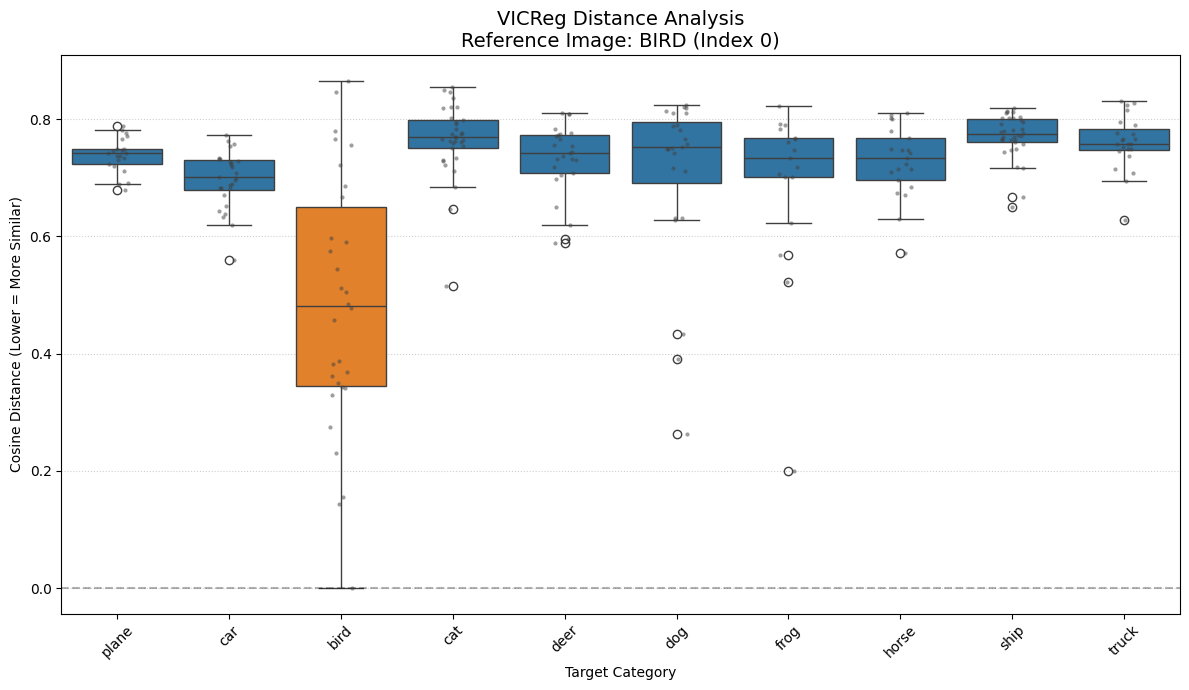

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def plot_vicreg_distances(model, dataloader, device, ref_idx=0):
    """
    Plots a boxplot of cosine distances from a reference image to all other 
    images in a batch, grouped by CIFAR-10 class.
    """
    model.eval()
    
    # 1. Grab a single batch and handle list structures (common in VICReg loaders)
    batch = next(iter(dataloader))
    
    # Unpack based on common VICReg/PyTorch structures
    if isinstance(batch, (list, tuple)):
        images, labels = batch[0], batch[1]
    else:
        raise ValueError("Unexpected batch format. Expected (images, labels).")

    # If VICReg loader returns [aug1, aug2], take the first augmentation
    if isinstance(images, (list, tuple)):
        images = images[0]

    images = images.to(device)
    labels = labels.to(device)
    
    # 2. Extract and Normalize Embeddings
    with torch.no_grad():
        # Using the backbone output is standard for evaluation
        embeddings = model(images) 
        # Normalize to unit length for Cosine Similarity/Distance
        embeddings = F.normalize(embeddings, p=2, dim=1)
    
    # 3. Select Reference Element
    ref_embedding = embeddings[ref_idx].unsqueeze(0) 
    ref_label_idx = labels[ref_idx].item()
    
    # 4. Compute Cosine Distances: Distance = 1 - Similarity
    # Similarity is the dot product of normalized vectors
    similarities = torch.mm(ref_embedding, embeddings.t()).squeeze()
    distances = 1 - similarities
    
    # 5. Prepare Dataframe
    cifar10_classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    ref_class_name = cifar10_classes[ref_label_idx]
    
    df = pd.DataFrame({
        'Distance': distances.cpu().numpy(),
        'Category': [cifar10_classes[l] for l in labels.cpu().numpy()]
    })
    
    # 6. Plotting
    plt.figure(figsize=(12, 7))
    
    # Highlight the reference category with a different color
    palette = {cat: "#ff7f0e" if cat == ref_class_name else "#1f77b4" for cat in cifar10_classes}
    
    sns.boxplot(x='Category', y='Distance', data=df, palette=palette, order=cifar10_classes)
    sns.stripplot(x='Category', y='Distance', data=df, color=".25", size=3, alpha=0.5, order=cifar10_classes)
    
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    plt.title(f"VICReg Distance Analysis\nReference Image: {ref_class_name.upper()} (Index {ref_idx})", fontsize=14)
    plt.ylabel("Cosine Distance (Lower = More Similar)")
    plt.xlabel("Target Category")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE SETUP ---
plot_vicreg_distances(model, train_loader, DEVICE, ref_idx=0)

[INFO    ][2026-03-20 10:37:17][matplotlib.category ][update                   ] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO    ][2026-03-20 10:37:17][matplotlib.category ][update                   ] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_904/1404539807.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Distance', data=df, capsize=.2, palette='viridis')


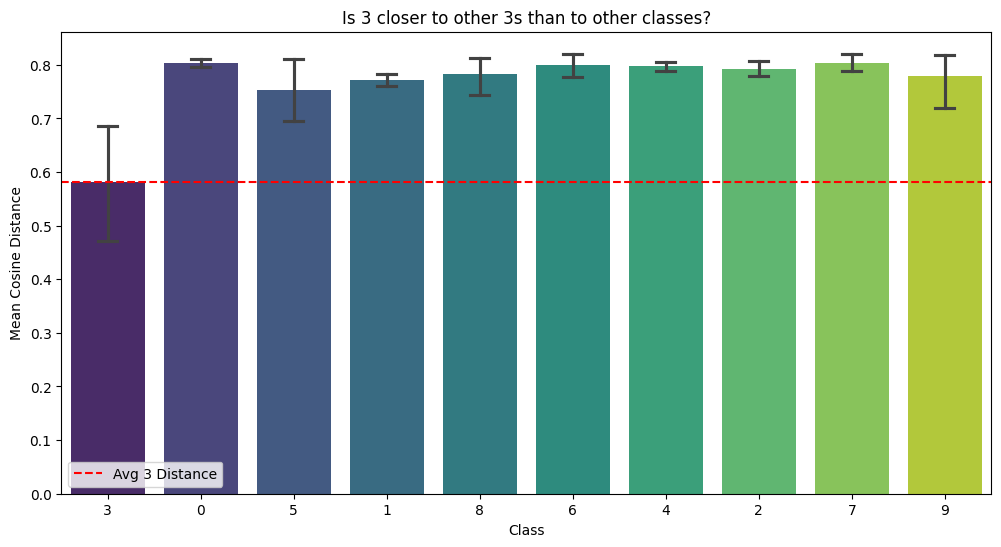

In [ ]:
def plot_class_distributions(model, dataloader, device, ref_idx=0):
    model.eval()
    
    # 1. Get a large batch to have enough samples per class
    batch = next(iter(dataloader))
    images, labels = batch[0], batch[1]
    
    # Handle the VICReg [aug1, aug2] list if necessary
    if isinstance(images, (list, tuple)):
        images = images[0]
        
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        # CRITICAL: If your model has a projector, use ONLY the backbone here
        # Example: embeddings = model.backbone(images)
        embeddings = model(images) 
        embeddings = F.normalize(embeddings, p=2, dim=1)
    
    # 2. Reference Image Info
    ref_emb = embeddings[ref_idx].unsqueeze(0)
    ref_label = labels[ref_idx].item()
    cifar10_classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
    ref_name = cifar10_classes[ref_label]

    # 3. Compute Distances to EVERYTHING in the batch
    # Distance = 1 - Cosine Similarity
    dist = 1 - torch.mm(ref_emb, embeddings.t()).squeeze()
    
    df = pd.DataFrame({
        'Distance': dist.cpu().numpy(),
        'Class': [cifar10_classes[l] for l in labels.cpu().numpy()]
    })

    # 4. Visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Class', y='Distance', data=df, capsize=.2, palette='viridis')
    plt.axhline(y=df[df['Class'] == ref_name]['Distance'].mean(), 
                color='r', linestyle='--', label=f'Avg {ref_name} Distance')
    
    plt.title(f"Is {ref_name.upper()} closer to other {ref_name.upper()}s than to other classes?")
    plt.ylabel("Mean Cosine Distance")
    plt.legend()
    plt.show()


plot_class_distributions(model, train_loader, DEVICE, ref_idx=0)

In [ ]:
import torch
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

def get_similarity_distributions(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for imgs, target in dataloader:
            # Get embeddings from the backbone (not the projector)
            emb = model(imgs.to(device))
            embeddings.append(F.normalize(emb, p=2, dim=1))
            labels.append(target)
            
    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)
    
    # Compute Cosine Similarity Matrix
    sim_matrix = torch.mm(embeddings, embeddings.t()).cpu().numpy()
    
    # Create masks for same-class vs different-class
    label_matrix = labels.unsqueeze(0) == labels.unsqueeze(1)
    
    # Flatten and extract values (excluding self-similarity on diagonal)
    mask_diag = torch.eye(len(labels)).bool()
    intra_class = sim_matrix[label_matrix & ~mask_diag]
    inter_class = sim_matrix[~label_matrix]
    
    return intra_class, inter_class

# Plotting
sns.kdeplot(intra_class, label="Same Class (Intra)", fill=True)
sns.kdeplot(inter_class, label="Different Class (Inter)", fill=True)
plt.title("Cosine Similarity Distribution after VICReg")
plt.xlabel("Cosine Similarity")
plt.show()

NameError: name 'intra_class' is not defined

In [ ]:
z1

tensor([[0.0248, 0.8857, 2.1805,  ..., 0.0481, 0.1758, 0.2953],
        [0.3240, 1.8472, 0.6252,  ..., 0.1043, 1.4608, 2.0851],
        [0.9840, 0.6637, 0.5745,  ..., 1.6110, 0.6427, 2.2581],
        ...,
        [0.0704, 0.2288, 0.0600,  ..., 1.4222, 1.4709, 0.0056],
        [0.6610, 0.1783, 0.4588,  ..., 0.9335, 0.9054, 0.0000],
        [0.4789, 0.7912, 0.0314,  ..., 0.0000, 0.3439, 1.5470]],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [ ]:
target

tensor([2, 3, 2, 1, 8, 7, 9, 4, 4, 6, 8, 1, 4, 4, 9, 6, 8, 2, 4, 4, 4, 3, 6, 7,
        2, 6, 9, 6, 1, 4, 1, 2, 5, 7, 1, 6, 3, 6, 4, 9, 1, 7, 9, 3, 5, 5, 7, 9,
        5, 8, 4, 6, 3, 4, 4, 2, 2, 8, 0, 5, 6, 8, 6, 1, 1, 4, 6, 2, 4, 4, 9, 0,
        2, 9, 2, 4, 1, 4, 6, 7, 2, 5, 5, 2, 2, 7, 9, 0, 4, 5, 5, 9, 1, 6, 2, 1,
        3, 9, 7, 3, 2, 0, 8, 0, 6, 0, 6, 5, 1, 3, 0, 0, 5, 0, 0, 7, 1, 5, 5, 9,
        9, 2, 2, 3, 1, 6, 6, 2, 2, 4, 1, 0, 4, 1, 7, 1, 2, 1, 0, 2, 0, 1, 9, 9,
        8, 8, 4, 4, 5, 0, 3, 0, 8, 4, 0, 8, 2, 8, 5, 2, 0, 9, 5, 6, 2, 0, 3, 7,
        7, 2, 3, 1, 0, 1, 6, 3, 2, 3, 7, 7, 5, 0, 6, 9, 6, 5, 5, 8, 5, 4, 3, 0,
        8, 6, 9, 2, 2, 3, 7, 6, 6, 5, 2, 3, 3, 5, 0, 4, 4, 2, 0, 2, 3, 0, 6, 3,
        0, 4, 9, 5, 6, 2, 5, 3, 4, 3, 4, 2, 2, 9, 7, 8, 4, 7, 8, 2, 1, 2, 2, 6,
        4, 8, 0, 0, 8, 6, 3, 4, 4, 2, 9, 9, 1, 9, 9, 5])

In [ ]:
!pip install umap-learn --break-system-packages

/tmp/ipykernel_820/1860782729.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


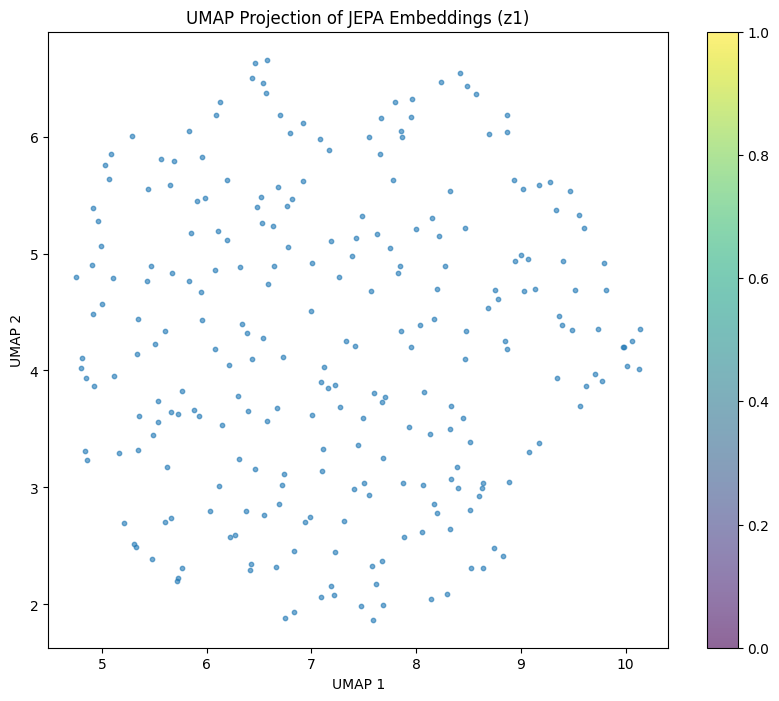

In [ ]:
import umap
import matplotlib.pyplot as plt
import torch

# 1. Prepare your data
# 'z1' is your tensor from the model (Batch, Features)
# We detach from the graph and move to CPU
embeddings = z1.detach().cpu().numpy()

# 2. Initialize and fit UMAP
# n_neighbors: low = local structure, high = global structure
# min_dist: how tightly UMAP packs points together
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine'  # Use cosine because JEPA/SSL relies on angular similarity
)

# 3. Transform the data to 2D
embedding_2d = reducer.fit_transform(embeddings)

# 4. Plotting
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    s=10,      # point size
    alpha=0.6, # transparency
    cmap='Spectral'
)
plt.title('UMAP Projection of JEPA Embeddings (z1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar()
plt.show()